# Práctica Final NLP — Ejercicio 2: Etapa de preprocesado de texto

**Bootcamp IA · Módulo de NLP**

En este notebook construimos la **etapa de preprocesado** de las reviews: limpiamos y normalizamos el texto para dejarlo en un
formato adecuado para vectorizar.

Todo el procesado se reúne en una única función de Python
(`preprocesar`) que se apoya en varias **sub-funciones**, cada una encargada de una tarea concreta (pasar a minúsculas, quitar puntuación, eliminar stopwords, lematizar, etc.)

## Contenido del notebook
1. Carga de datos
2. Diseño de la función de preprocesado
   - 2.1 Sub-funciones
   - 2.2 Función principal
3. Aplicación al corpus
4. Guardado del dataset preprocesado

## 0. Librerías

In [ ]:
import gzip, json, re, unicodedata

import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

# Recursos de NLTK necesarios
for r in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(r, quiet=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

## 1. Carga de datos

Partimos del mismo corpus del Ejercicio 1 (*Musical Instruments*) y reconstruimos la etiqueta de
sentimiento: 4-5 estrellas para positivo, 1-2 para negativo, y descartamos las de 3 estrellas.

In [ ]:
PATH = 'data/reviews_Musical_Instruments_5.json.gz'

with gzip.open(PATH, 'rt', encoding='utf-8') as f:
    registros = [json.loads(linea) for linea in f]

df = pd.DataFrame(registros)[['reviewText', 'overall']].copy()
df['reviewText'] = df['reviewText'].fillna('').astype(str)
df = df[df['reviewText'].str.strip() != ''].reset_index(drop=True)

def estrellas_a_sentimiento(estrellas):
    if estrellas >= 4:
        return 'positivo'
    elif estrellas <= 2:
        return 'negativo'
    return 'neutro'

df['sentimiento'] = df['overall'].apply(estrellas_a_sentimiento)
df = df[df['sentimiento'] != 'neutro'].reset_index(drop=True)
df['target'] = (df['sentimiento'] == 'positivo').astype(int)

print('Reviews para clasificación binaria:', len(df))
df.head(3)

Reviews para clasificación binaria: 9482


,reviewText,overall,sentimiento,target
0,"Not much to write about here, but it does exac...",5.0,positivo,1
1,The product does exactly as it should and is q...,5.0,positivo,1
2,The primary job of this device is to block the...,5.0,positivo,1


## 2. Diseño de la función de preprocesado

El preprocesado se compone de los siguientes pasos, pensados para texto en inglés:

1. Pasar a **minúsculas**.
2. Eliminar **URLs y etiquetas HTML**.
3. Normalizar las **contracciones de negación** (`don't` se convierte en `do not`), para no perder
   las negaciones, que son importantes en sentimiento.
4. **Normalizar Unicode** (quitar acentos y caracteres raros).
5. Dejar **solo letras** (se eliminan números, signos de puntuación y símbolos).
6. **Tokenizar** el texto.
7. Eliminar **stopwords** (conservando las palabras de negación) y tokens muy cortos.
8. **Lematizar** cada token para reducirlo a su forma base.

Cada paso se implementa en una sub-función y la función principal `preprocesar` las encadena.

### 2.1 Sub-funciones

In [ ]:
lematizador = WordNetLemmatizer()

# Conservamos las negaciones porque aportan sentimiento (p. ej. "not good")
NEGACIONES = {'no', 'not', 'nor', 'none', 'never', 'neither'}
STOPWORDS = set(stopwords.words('english')) - NEGACIONES


def a_minusculas(texto):
    return texto.lower()


def eliminar_urls_html(texto):
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'<.*?>', ' ', texto)
    return texto


def expandir_negaciones(texto):
    # don't, doesn't, isn't... pasan a "... not"
    return re.sub(r"n't\b", ' not', texto)


def normalizar_unicode(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return texto.encode('ascii', 'ignore').decode('utf-8')


def dejar_solo_letras(texto):
    return re.sub(r'[^a-z\s]', ' ', texto)


def tokenizar(texto):
    return texto.split()


def eliminar_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS and len(t) >= 2]


def lematizar(tokens):
    return [lematizador.lemmatize(t) for t in tokens]

### 2.2 Función principal

In [ ]:
def preprocesar(texto):
    """Aplica todo el preprocesado a una review y devuelve el texto limpio."""
    texto = a_minusculas(texto)
    texto = eliminar_urls_html(texto)
    texto = expandir_negaciones(texto)
    texto = normalizar_unicode(texto)
    texto = dejar_solo_letras(texto)
    tokens = tokenizar(texto)
    tokens = eliminar_stopwords(tokens)
    tokens = lematizar(tokens)
    return ' '.join(tokens)


# Comprobamos la función con un ejemplo inventado
ejemplo = "I don't like this GUITAR... it's <b>terrible</b>! Visit http://x.com"
print('Original:', ejemplo)
print('Limpio  :', preprocesar(ejemplo))

Original: I don't like this GUITAR... it's <b>terrible</b>! Visit http://x.com


Limpio  : not like guitar terrible visit


## 3. Aplicación al corpus

Aplicamos la función a todas las reviews y comparamos el texto original con el preprocesado.

In [ ]:
df['texto_limpio'] = df['reviewText'].apply(preprocesar)

# Mostramos algunos ejemplos antes / después
for i in [0, 1, 2]:
    print('ORIGINAL:', df['reviewText'].iloc[i][:160])
    print('LIMPIO  :', df['texto_limpio'].iloc[i][:160])
    print('-' * 80)

ORIGINAL: Not much to write about here, but it does exactly what it's supposed to. filters out the pop sounds. now my recordings are much more crisp. it is one of the low
LIMPIO  : not much write exactly supposed filter pop sound recording much crisp one lowest price pop filter amazon might well buy honestly work despite pricing
--------------------------------------------------------------------------------
ORIGINAL: The product does exactly as it should and is quite affordable.I did not realized it was double screened until it arrived, so it was even better than I had expec
LIMPIO  : product exactly quite affordable not realized double screened arrived even better expected added bonus one screen carry small hint smell old grape candy used bu
--------------------------------------------------------------------------------
ORIGINAL: The primary job of this device is to block the breath that would otherwise produce a popping sound, while allowing your voice to pass through with no notic

Medimos el efecto del preprocesado sobre la longitud de las reviews y el tamaño del vocabulario.

In [ ]:
palabras_antes = df['reviewText'].str.split().apply(len)
palabras_despues = df['texto_limpio'].str.split().apply(len)

vocab_antes = set(p for t in df['reviewText'].str.lower() for p in t.split())
vocab_despues = set(p for t in df['texto_limpio'] for p in t.split())

print(f'Palabras por review (media)  antes: {palabras_antes.mean():.1f}   después: {palabras_despues.mean():.1f}')
print(f'Vocabulario (palabras únicas) antes: {len(vocab_antes):,}   después: {len(vocab_despues):,}')
print(f'Reducción de vocabulario: {(1 - len(vocab_despues)/len(vocab_antes))*100:.1f}%')

Palabras por review (media)  antes: 88.8   después: 45.4
Vocabulario (palabras únicas) antes: 49,033   después: 16,255
Reducción de vocabulario: 66.8%


/var/folders/fc/cdvkm_gd4w5472h7gr4mhpzr0000gn/T/ipykernel_19324/331059967.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=comparativa.index, y=comparativa['palabras medias'],


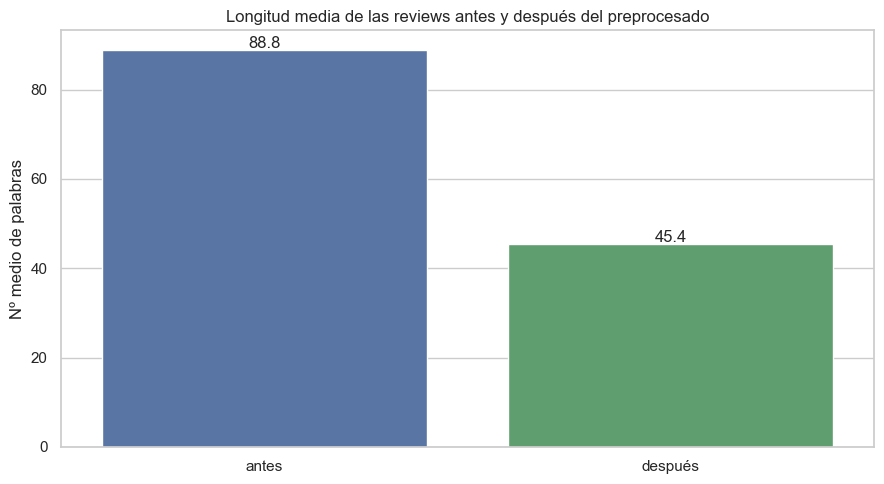

In [ ]:
# Comparación visual de la longitud media de las reviews
comparativa = pd.DataFrame({
    'antes': [palabras_antes.mean()],
    'después': [palabras_despues.mean()],
}).T.rename(columns={0: 'palabras medias'})

ax = sns.barplot(x=comparativa.index, y=comparativa['palabras medias'],
                 palette=['#4C72B0', '#55A868'])
ax.set_title('Longitud media de las reviews antes y después del preprocesado')
ax.set_xlabel('')
ax.set_ylabel('Nº medio de palabras')
for i, v in enumerate(comparativa['palabras medias']):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center')
plt.tight_layout()
plt.show()

El preprocesado reduce tanto la longitud de las reviews como el vocabulario,
al eliminar stopwords, puntuación y variantes de una misma palabra.

## 4. Guardado del dataset preprocesado

Guardamos el resultado en un CSV para reutilizarlo directamente en el Ejercicio 3 sin repetir el
preprocesado.

In [ ]:
salida = df[['reviewText', 'texto_limpio', 'sentimiento', 'target']].copy()

# Algunas reviews pueden quedar vacías tras limpiar (solo tenían stopwords o símbolos)
vacias = (salida['texto_limpio'].str.strip() == '').sum()
print('Reviews que quedan vacías tras el preprocesado:', vacias)
salida = salida[salida['texto_limpio'].str.strip() != ''].reset_index(drop=True)

salida.to_csv('data/reviews_preprocesado.csv', index=False)
print('Guardado data/reviews_preprocesado.csv con', len(salida), 'reviews')

Reviews que quedan vacías tras el preprocesado: 0


Guardado data/reviews_preprocesado.csv con 9482 reviews
